# Titanic: The Story in the Data

## Prologue

On **15 April 1912**, during her maiden voyage, the RMS Titanic sank after colliding with an iceberg. There were not enough lifeboats for everyone aboard, and **1,502** of the **2,224** passengers and crew died ([Kaggle competition description](https://www.kaggle.com/competitions/titanic)).

Kaggle gives us the records of **1,309 passengers**. For 891 of them we know whether they survived (`train.csv`); for the other 418 the answer is hidden (`test.csv`). Our question is simple:

> **Who survived, and can a model learn why?**

| Chapter | Question |
|---|---|
| 1 | Who was aboard? |
| 2 | Who survived? |
| 3 | Whose records are missing? |
| 4 | Can a model learn the story? |
| 5 | Where does the model fail? |
| 6 | What does it predict for the 418 hidden passengers? |
| Epilogue | What did the data tell us, and what could it not tell? |

Each chapter first tells the story, then keeps the details in a **🔧 Technical note**. Everything here comes from the data; facts from outside the data are only stated with a source link.

| Column | Meaning | Column | Meaning |
|---|---|---|---|
| `Survived` | 0 = died, 1 = survived | `Parch` | parents / children aboard |
| `Pclass` | ticket class 1, 2, 3 | `Ticket` | ticket number |
| `Name` | name, includes a title | `Fare` | ticket price |
| `Sex` | male / female | `Cabin` | cabin number |
| `Age` | age in years | `Embarked` | port: C = Cherbourg, Q = Queenstown, S = Southampton |
| `SibSp` | siblings / spouse aboard | | |

### Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["axes.grid.axis"] = "y"

# Chart colors: blue = not survived, orange = survived, gray = single measure
SURVIVAL_COLORS = {0: "#2a78d6", 1: "#eb6834"}
SURVIVAL_LABELS = {0: "Not survived", 1: "Survived"}
SEX_COLORS = {"male": "#1baf7a", "female": "#4a3aa7"}
NEUTRAL = "#6b6a65"
INK = "#52514e"
RATE_LABEL = "Survival rate"


def label_bars(ax, fmt="{:.0%}"):
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9, color=INK)


def rate_bar(ax, rates, title, xlabel):
    ax.bar(rates.index.astype(str), rates.values, color=NEUTRAL, width=0.6)
    ax.axhline(train["Survived"].mean(), color=INK, linestyle="--", linewidth=1)
    label_bars(ax)
    ax.set(ylim=(0, 1), title=title, xlabel=xlabel, ylabel=RATE_LABEL)

In [2]:
from pathlib import Path

# Local: dataset/  ·  Kaggle: /kaggle/input/...
KAGGLE_INPUT = Path("/kaggle/input")
DATA_DIR = next(KAGGLE_INPUT.rglob("train.csv")).parent if KAGGLE_INPUT.exists() else Path("dataset")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
print(f"Data: {DATA_DIR} | Train: {train.shape} | Test: {test.shape}")
train.head()

Data: dataset | Train: (891, 12) | Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Chapter 1: Who Was Aboard?

Before asking who survived, we meet the passengers: how old they were, which class they travelled in, where they boarded and whether they travelled with family.

In [3]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
desc = train[num_cols].describe().T
desc["skew"] = train[num_cols].skew()
display(desc.round(2))

# Train vs test
compare = ["Age", "SibSp", "Parch", "Fare"]
display(pd.concat({"train": train[compare].agg(["median", "max"]).T,
                   "test": test[compare].agg(["median", "max"]).T}, axis=1).round(2))

print("Passengers with Fare = 0:", (train.Fare == 0).sum())
print("Max fare ticket(s):", train.loc[train.Fare == train.Fare.max(), "Ticket"].unique(),
      "·", (train.Fare == train.Fare.max()).sum(), "passengers")

,count,mean,std,min,25%,50%,75%,max,skew
Survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00,0.48
Pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00,-0.63
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00,0.39
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00,3.70
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00,2.75
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33,4.79


train           test        
      median     max median     max
Age    28.00   80.00  27.00   76.00
SibSp   0.00    8.00   0.00    8.00
Parch   0.00    6.00   0.00    9.00
Fare   14.45  512.33  14.45  512.33

Passengers with Fare = 0: 15
Max fare ticket(s): ['PC 17755'] · 3 passengers


In [4]:
display(train.describe(include="object").T)

composition = pd.concat({
    col: train[col].value_counts(normalize=True).mul(100).round(1) for col in ["Sex", "Pclass", "Embarked"]
}).to_frame("%")
print("Travelling without family:", round(((train.SibSp + train.Parch) == 0).mean() * 100, 1), "%")
composition

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


Travelling without family: 60.3 %


%
Sex      male    64.8
         female  35.2
Pclass   3       55.1
         1       24.2
         2       20.7
Embarked S       72.4
         C       18.9
         Q        8.7

> **📖 The passengers**
>
> - **Mostly men:** 65% of the passengers were male.
> - **Mostly third class:** 55% travelled in 3rd class, 24% in 1st, 21% in 2nd.
> - **Mostly young adults:** median age 28, from babies of a few months (0.42) to 80.
> - **Mostly alone:** 60% had no family aboard. A few families were very large (up to 8 siblings).
> - **Mostly from Southampton:** 72% boarded there, 19% in Cherbourg, 9% in Queenstown.
> - **Very unequal fares:** half paid less than 14.45, while three passengers on one ticket paid 512.33. `Fare` is the price of a **ticket**, which a whole group could share. 15 passengers paid nothing.
> - **Text columns hide information:** every `Name` is unique, 681 different tickets, 147 different cabins.

### 🔧 Technical note: data quality and types

In [5]:
features = [c for c in train.columns if c not in ["PassengerId", "Survived"]]
print("Duplicate rows (ignoring PassengerId), train:", train[features].duplicated().sum())
print("Duplicate rows (ignoring PassengerId), test: ", test[features].duplicated().sum())
print("Duplicate rows across train + test:           ", pd.concat([train[features], test[features]]).duplicated().sum())

missing = pd.DataFrame({
    "train_missing": train.isnull().sum(),
    "train_%": (train.isnull().mean() * 100).round(1),
    "test_missing": test.isnull().sum(),
    "test_%": (test.isnull().mean() * 100).round(1),
})
missing.query("train_missing > 0 or test_missing > 0").sort_values("train_%", ascending=False)

Duplicate rows (ignoring PassengerId), train: 0
Duplicate rows (ignoring PassengerId), test:  0
Duplicate rows across train + test:            0


,train_missing,train_%,test_missing,test_%
Cabin,687,77.1,327.0,78.2
Age,177,19.9,86.0,20.6
Embarked,2,0.2,0.0,0.0
Fare,0,0.0,1.0,0.2


> - **No duplicate rows** in train, in test or across both files.
> - **Missing values** have almost the same ratios in train and test: `Cabin` about 77%, `Age` about 20%, `Embarked` 2 rows in train only, `Fare` 1 row in test only. Chapter 3 tells their story.

pandas guesses column types from the file. They are technically valid but not always meaningful, so they are converted:

| Column | Before | After | Why |
|---|---|---|---|
| `Pclass` | int64 | ordered category | 1, 2, 3 are ordered labels, not amounts |
| `Sex`, `Embarked` | object | category | a few fixed values |
| `Name`, `Ticket`, `Cabin` | object | string | free text |
| other columns | unchanged | unchanged | already correct |

In [6]:
PCLASS_TYPE = pd.CategoricalDtype([1, 2, 3], ordered=True)
SEX_TYPE = pd.CategoricalDtype(["male", "female"])
EMBARKED_TYPE = pd.CategoricalDtype(["C", "Q", "S"])


def convert_types(df):
    df = df.copy()
    df["Pclass"] = df["Pclass"].astype(PCLASS_TYPE)
    df["Sex"] = df["Sex"].astype(SEX_TYPE)
    df["Embarked"] = df["Embarked"].astype(EMBARKED_TYPE)
    for col in ["Name", "Ticket", "Cabin"]:
        df[col] = df[col].astype("string")
    return df


dtypes_before = train.dtypes.astype(str)
missing_before = train.isnull().sum()
train, test = convert_types(train), convert_types(test)

pd.DataFrame({
    "before": dtypes_before,
    "train_after": train.dtypes.astype(str),
    "test_after": test.dtypes.astype(str),
    "missing_unchanged": train.isnull().sum() == missing_before,
})

,before,train_after,test_after,missing_unchanged
Age,float64,float64,float64,True
Cabin,object,string,string,True
Embarked,object,category,category,True
Fare,float64,float64,float64,True
Name,object,string,string,True
Parch,int64,int64,int64,True
PassengerId,int64,int64,int64,True
Pclass,int64,category,category,True
Sex,object,category,category,True
SibSp,int64,int64,int64,True


> Train and test now have **identical types**, and no missing count changed, so nothing was silently filled or dropped.

## Chapter 2: Who Survived?

There were not enough lifeboats for everyone aboard ([Kaggle](https://www.kaggle.com/competitions/titanic)). Which passengers survived?

,count,%
Survived,,
Not survived,549,61.6
Survived,342,38.4


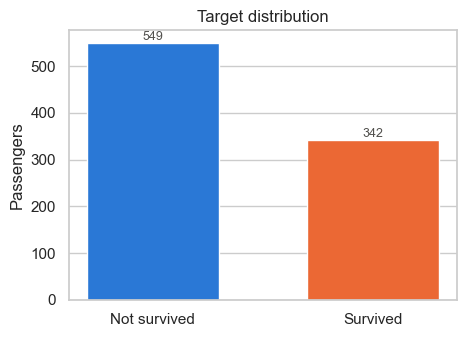

In [7]:
balance = train["Survived"].value_counts().to_frame("count")
balance["%"] = (balance["count"] / len(train) * 100).round(1)
display(balance.rename(index=SURVIVAL_LABELS))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar([SURVIVAL_LABELS[0], SURVIVAL_LABELS[1]], balance["count"].sort_index(),
       color=[SURVIVAL_COLORS[0], SURVIVAL_COLORS[1]], width=0.6)
label_bars(ax, fmt="{:.0f}")
ax.set(title="Target distribution", ylabel="Passengers")
plt.show()

In [8]:
rates = pd.concat({
    col: train.groupby(col, observed=True)["Survived"].agg(passengers="size", survival_rate="mean")
    for col in ["Sex", "Pclass", "Embarked"]
})
rates.index.names = ["feature", "value"]
rates.round(3)

passengers  survival_rate
feature  value                            
Sex      male           577          0.189
         female         314          0.742
Pclass   1              216          0.630
         2              184          0.473
         3              491          0.242
Embarked C              168          0.554
         Q               77          0.390
         S              644          0.337

> **📖 Women and higher classes survived more often**
>
> - Only **38%** of the passengers in our data survived. If we guessed "died" for everyone, we would already be right 61.6% of the time.
> - **Sex made the biggest difference:** 74% of women survived, only 19% of men.
> - **Class mattered too:** 63% of 1st class passengers survived, 47% of 2nd class, 24% of 3rd class.
> - **The port looks important** (Cherbourg 55%, Southampton 34%), but the technical note below shows this is mostly about *who* boarded there.

### 2.1 Children, classes, fares and families

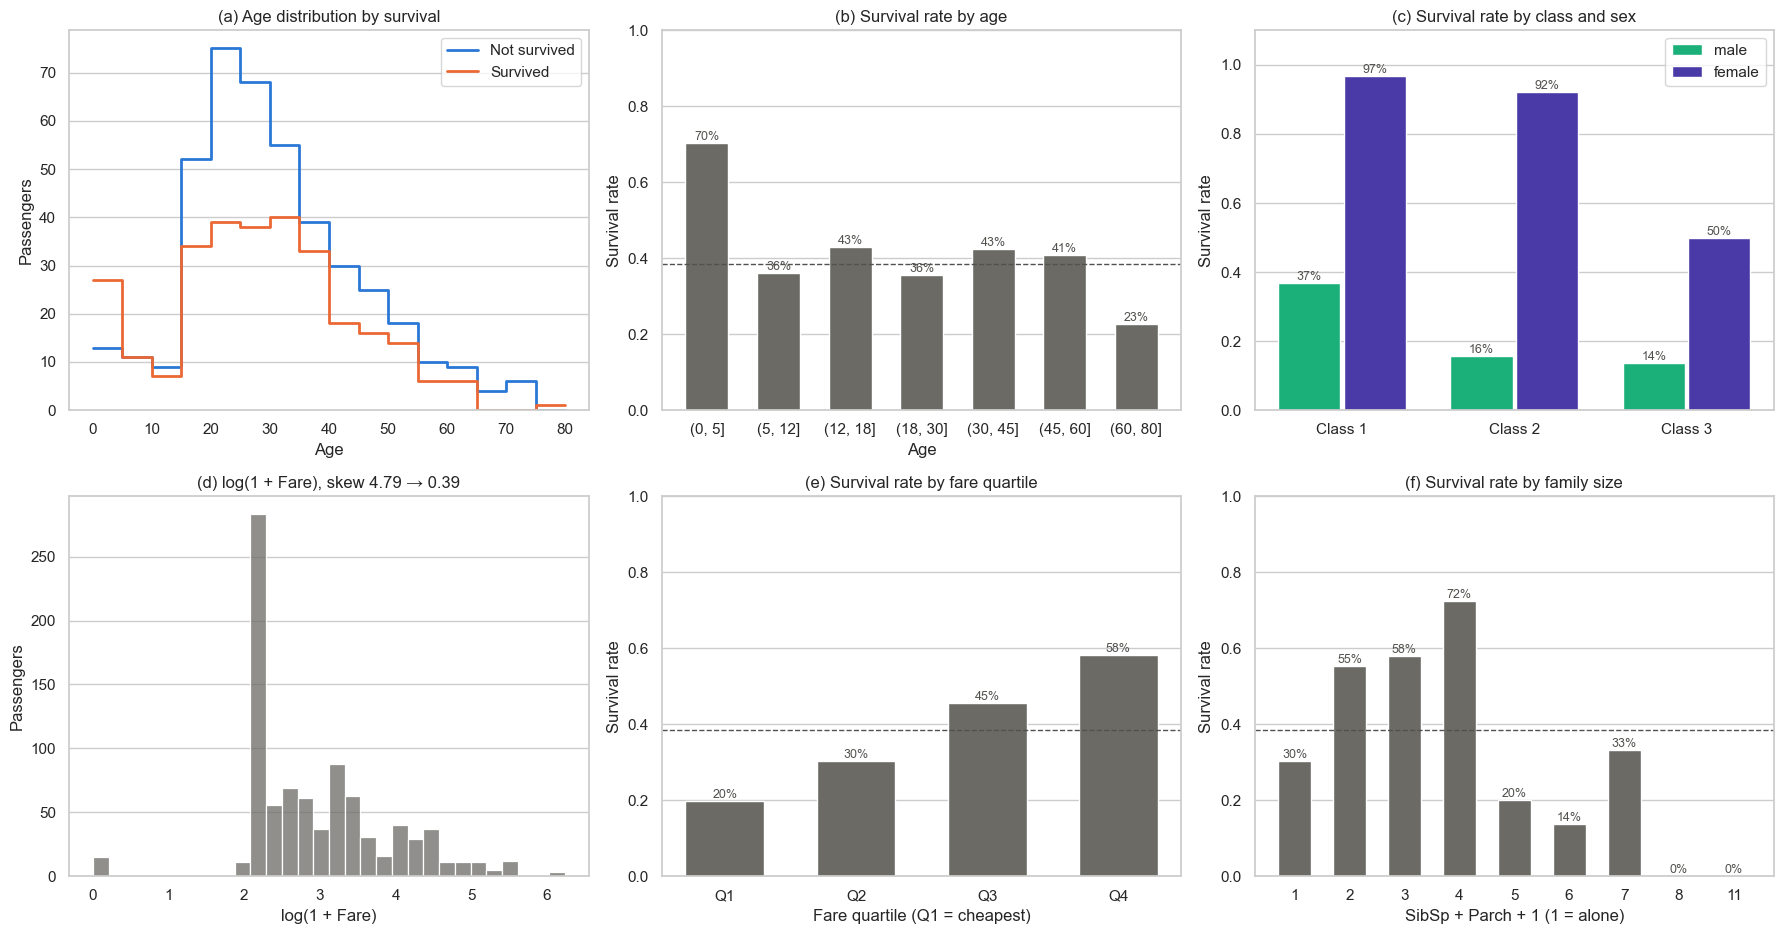

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5))

# (a) Age distribution by survival
ax = axes[0, 0]
for value in [0, 1]:
    sns.histplot(train.loc[train.Survived == value, "Age"].dropna(), bins=range(0, 85, 5), element="step",
                 fill=False, linewidth=2, color=SURVIVAL_COLORS[value], label=SURVIVAL_LABELS[value], ax=ax)
ax.set(title="(a) Age distribution by survival", xlabel="Age", ylabel="Passengers")
ax.legend()

# (b) Survival rate by age band
rate_bar(axes[0, 1], train.groupby(pd.cut(train.Age, [0, 5, 12, 18, 30, 45, 60, 80]), observed=True)["Survived"].mean(),
         "(b) Survival rate by age", "Age")

# (c) Sex x Pclass
ax = axes[0, 2]
sex_class = train.groupby(["Pclass", "Sex"], observed=True)["Survived"].mean().unstack()
x, width = np.arange(3), 0.36
for i, sex in enumerate(["male", "female"]):
    ax.bar(x + (i - 0.5) * (width + 0.02), sex_class[sex], width=width, color=SEX_COLORS[sex], label=sex)
label_bars(ax)
ax.set_xticks(x, [f"Class {c}" for c in sex_class.index])
ax.set(ylim=(0, 1.1), title="(c) Survival rate by class and sex", ylabel=RATE_LABEL)
ax.legend()

# (d) log(1 + Fare)
ax = axes[1, 0]
sns.histplot(np.log1p(train.Fare), bins=30, color=NEUTRAL, ax=ax)
ax.set(title=f"(d) log(1 + Fare), skew {train.Fare.skew():.2f} → {np.log1p(train.Fare).skew():.2f}",
       xlabel="log(1 + Fare)", ylabel="Passengers")

# (e) Survival rate by fare quartile
rate_bar(axes[1, 1], train.groupby(pd.qcut(train.Fare, 4, labels=["Q1", "Q2", "Q3", "Q4"]), observed=True)["Survived"].mean(),
         "(e) Survival rate by fare quartile", "Fare quartile (Q1 = cheapest)")

# (f) Survival rate by family size
family_size = train.SibSp + train.Parch + 1
rate_bar(axes[1, 2], train.groupby(family_size)["Survived"].mean(), "(f) Survival rate by family size", "SibSp + Parch + 1 (1 = alone)")

plt.tight_layout()
plt.show()

In [10]:
age_group = np.select([train.Age.isna(), train.Age <= 12], ["age unknown", "child (<=12)"], "adult (>12)")
display(train.groupby([train.Sex, age_group], observed=True)["Survived"].agg(passengers="size", survival_rate="mean").round(3))

train.groupby(family_size)["Survived"].agg(passengers="size", survival_rate="mean").round(3).T

passengers  survival_rate
Sex                                           
male   adult (>12)          416          0.173
       age unknown          124          0.129
       child (<=12)          37          0.568
female adult (>12)          229          0.777
       age unknown           53          0.679
       child (<=12)          32          0.594

,1,2,3,4,5,6,7,8,11
passengers,537.000,161.000,102.000,29.000,15.0,22.000,12.000,6.0,7.0
survival_rate,0.304,0.553,0.578,0.724,0.2,0.136,0.333,0.0,0.0


> **📖 Women and children survived more often, but not all of them**
>
> - **(a, b) Children:** 70% of young children (age 0 to 5) survived, but only 23% of passengers over 60. The table shows the child advantage was **for boys**: boys 57% versus adult men 17%. Girls (59%) did not do better than adult women (78%).
> - **(c) Class changed the pattern:** women in 1st and 2nd class survived at **97% and 92%**, in 3rd class only **50%**. Men: 37% in 1st class, then 16% and 14%. A 3rd class woman still survived more often than a 1st class man. **Sex made the biggest difference, class changed its size.**
> - **(d, e) Money:** survival rose steadily with fare, from **20%** in the cheapest quarter to **58%** in the most expensive.
> - **(f) Families:** people alone survived 30%, small families of 2 to 4 people **55% to 72%**, families of 5 or more at most 33%. Nobody from the families of 8 and 11 people survived in our data.
> - Passengers **whose age is unknown** survived less. Chapter 3 follows this clue.

### 2.2 What the names reveal

Every name follows the pattern `Surname, Title. First names`. The title tells us more than sex: **Master** was used for boys. Grouping: `Mlle` and `Ms` become `Miss`, `Mme` becomes `Mrs`, everything other than Mr, Mrs, Miss and Master becomes `Rare`.

In [11]:
TITLE_PATTERN = r",\s*([^.]+)\."
raw_titles = pd.DataFrame({
    "train": train["Name"].str.extract(TITLE_PATTERN, expand=False).str.strip().value_counts(),
    "test": test["Name"].str.extract(TITLE_PATTERN, expand=False).str.strip().value_counts(),
}).fillna(0).astype(int)
raw_titles.sort_values("train", ascending=False).T

Name,Mr,Miss,Mrs,Master,Dr,Rev,Major,Col,Mlle,Sir,Ms,Capt,Mme,Lady,Jonkheer,Don,the Countess,Dona
train,517,182,125,40,7,6,2,2,2,1,1,1,1,1,1,1,1,0
test,240,78,72,21,1,2,0,2,0,0,1,0,0,0,0,0,0,1


In [12]:
TITLE_TYPE = pd.CategoricalDtype(["Mr", "Mrs", "Miss", "Master", "Rare"])
TITLE_MAP = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}


def extract_title(df):
    raw = df["Name"].str.extract(TITLE_PATTERN, expand=False).str.strip().replace(TITLE_MAP)
    return raw.where(raw.isin(TITLE_TYPE.categories), "Rare").astype(TITLE_TYPE)


train["Title"], test["Title"] = extract_title(train), extract_title(test)

pd.crosstab(train["Title"], train["Sex"]).join(
    train.groupby("Title", observed=True).agg(
        survival_rate=("Survived", "mean"),
        age_median=("Age", "median"),
        age_missing_train=("Age", lambda s: s.isna().sum()),
    )
).assign(test_passengers=test["Title"].value_counts(), age_missing_test=test.groupby("Title", observed=True)["Age"].apply(lambda s: s.isna().sum())).round(2)

,male,female,survival_rate,age_median,age_missing_train,test_passengers,age_missing_test
Title,,,,,,,
Mr,517,0,0.16,30.0,119,240,57
Mrs,0,126,0.79,35.0,17,72,10
Miss,0,185,0.70,21.0,36,79,15
Master,40,0,0.57,3.5,4,21,4
Rare,20,3,0.35,48.5,1,6,0


> **📖 Boys and men were not the same**
>
> - Mr, Miss, Mrs and Master cover **97%** of the passengers. `Dona` appears only in test, and grouping sends it to `Rare`.
> - **Survival by title:** Mrs 79%, Miss 70%, **Master 57%**, Rare 35%, **Mr 16%**. Boys survived more than three times as often as men, a difference `Sex` alone cannot show.
> - **Median age by title:** Master 3.5, Miss 21, Mr 30, Mrs 35, Rare 48.5. This will help fill missing ages in Chapter 3.

### 🔧 Technical note: correlation

Categorical columns are encoded **temporarily**: `Pclass` as 1, 2, 3, `Sex` as male 0 and female 1, `Embarked` as one-hot columns because ports have no order.

> **📘 Reading correlation:** the **sign** gives the direction, the **absolute value** |r| gives the strength. `Pclass` at −0.338 is a *stronger* relationship than `Fare` at +0.257, so features are ranked by |r|. Rough guide: below 0.1 negligible, 0.1 to 0.3 weak, 0.3 to 0.5 moderate, 0.5 to 0.7 strong, above 0.7 very strong.

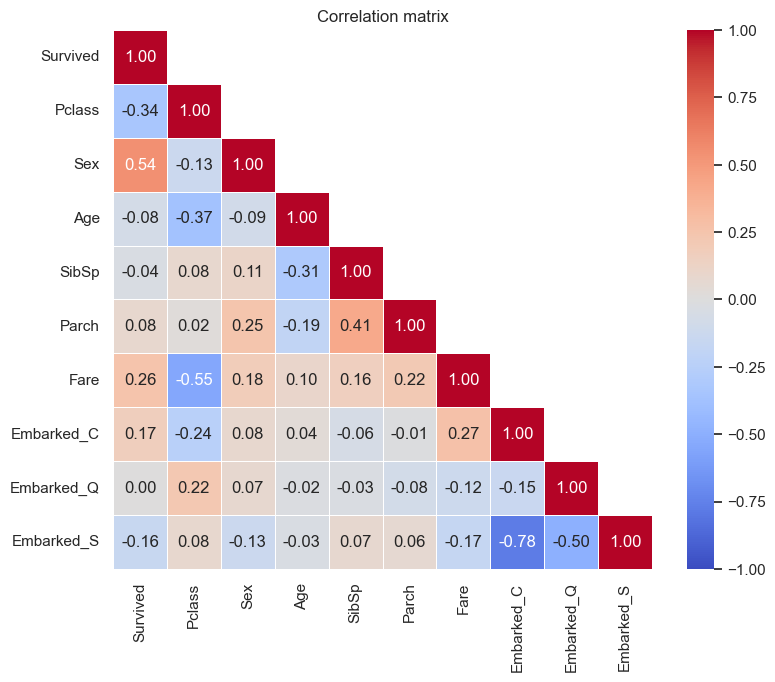

In [13]:
corr_df = pd.DataFrame({
    "Survived": train["Survived"],
    "Pclass": train["Pclass"].astype(int),
    "Sex": train["Sex"].cat.codes,  # male = 0, female = 1
    "Age": train["Age"],
    "SibSp": train["SibSp"],
    "Parch": train["Parch"],
    "Fare": train["Fare"],
}).join(pd.get_dummies(train["Embarked"], prefix="Embarked", dtype=int))
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.grid(False)
ax.set_title("Correlation matrix")
plt.show()

In [14]:
target_corr = corr["Survived"].drop("Survived")
display(target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).round(3).to_frame("r_with_Survived"))

# Class mix per port (row %), explains the Embarked_C correlation
pd.crosstab(train["Embarked"], train["Pclass"], normalize="index").round(2)

,r_with_Survived
Sex,0.543
Pclass,-0.338
Fare,0.257
Embarked_C,0.168
Embarked_S,-0.156
Parch,0.082
Age,-0.077
SibSp,-0.035
Embarked_Q,0.004


Pclass,1,2,3
Embarked,,,
C,0.51,0.10,0.39
Q,0.03,0.04,0.94
S,0.20,0.25,0.55


> - **With survival:** `Sex` **+0.54** (strong), `Pclass` **−0.34** (moderate), `Fare` **+0.26**, `Embarked_C` +0.17. `Age`, `SibSp` and `Parch` are all below |0.1|, yet section 2.1 showed they matter: Pearson only sees **straight line** relationships.
> - **Between features:** `Pclass` and `Fare` **−0.55** (partly the same information), `SibSp` and `Parch` **+0.41** (both count family members), `Pclass` and `Age` −0.37 (1st class passengers were older).
> - `Embarked_C` and `Embarked_S` at −0.78 is **artificial**: one-hot columns of the same variable exclude each other.
> - **The port story is really a class story:** 51% of Cherbourg passengers were 1st class, but only 3% of Queenstown passengers.
> - No real pair exceeds |0.8|, so there is no serious multicollinearity.

## Chapter 3: Whose Records Are Missing?

For some passengers the records are complete; for others, even the age is missing. **Whose records are missing, and does it matter?**

In [15]:
age_unknown = train["Age"].isna()
travel = np.where(train["SibSp"] + train["Parch"] == 0, "alone", "with family")
pd.concat({
    "Embarked": age_unknown.groupby(train["Embarked"], observed=True).mean(),
    "Pclass": age_unknown.groupby(train["Pclass"], observed=True).mean(),
    "Travelling": age_unknown.groupby(travel).mean(),
    "Sex": age_unknown.groupby(train["Sex"], observed=True).mean(),
}).mul(100).round(1).to_frame("% age unknown")

% age unknown
Embarked   C                     22.6
           Q                     63.6
           S                     14.0
Pclass     1                     13.9
           2                      6.0
           3                     27.7
Travelling alone                 24.8
           with family           12.4
Sex        male                  21.5
           female                16.9

> **📖 Missing ages are concentrated in Queenstown**
>
> - **Two out of three Queenstown passengers have no recorded age (64%)**, compared with 23% in Cherbourg and 14% in Southampton. 94% of Queenstown passengers travelled in 3rd class (Chapter 2, technical note).
> - Ages are also missing more often for **3rd class** (28%) and for people **travelling alone** (25% versus 12% with family).
> - The data does **not** tell us *why* these ages are missing. It does show that the missing values are **not random**, so "age unknown" is itself a piece of information worth keeping.

### 3.1 Filling the gaps

**Rule:** every fill value is learned from **train only** and applied to both files. The original columns are kept in `train_before` and `test_before`.

| Column | How it is filled | Why |
|---|---|---|
| `Age` | median age of the passenger's **title** | age differs strongly by title |
| `Embarked` | most frequent port in train | the fare evidence contradicts itself |
| `Fare` (test) | median fare of **3rd class, Southampton** | matches the passenger's class and port |

,count,mean,std,min,25%,50%,75%,max
before,714.0,29.70,14.53,0.42,20.12,28.0,38.0,80.0
after,891.0,29.39,13.27,0.42,21.00,30.0,35.0,80.0


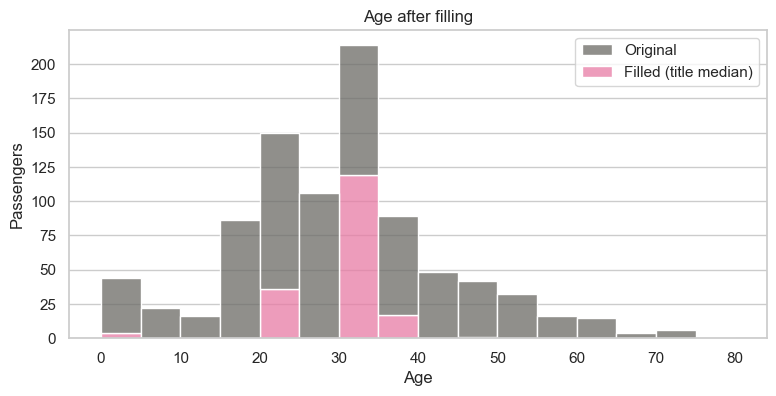

In [16]:
train_before, test_before = train[["Age", "Embarked", "Fare"]].copy(), test[["Age", "Embarked", "Fare"]].copy()

# Age
AGE_BY_TITLE = train.groupby("Title", observed=True)["Age"].median()


def fill_age(df):
    df = df.copy()
    df["Age"] = df["Age"].fillna(df["Title"].map(AGE_BY_TITLE).astype(float))
    return df


train, test = fill_age(train), fill_age(test)
display(pd.DataFrame({"before": train_before["Age"].describe(), "after": train["Age"].describe()}).round(2).T)

age_source = np.where(train_before["Age"].isna(), "Filled (title median)", "Original")
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(x=train["Age"], hue=age_source, hue_order=["Original", "Filled (title median)"], multiple="stack",
             bins=range(0, 85, 5), palette={"Original": NEUTRAL, "Filled (title median)": "#e87ba4"}, ax=ax)
ax.set(title="Age after filling", xlabel="Age", ylabel="Passengers")
plt.show()

> **📖 Age**
>
> - 177 ages filled in train, 86 in test: Mr 30, Mrs 35, Miss 21, **Master 3.5**, Rare 48.5. A boy with an unknown age now gets a child's age instead of 28.
> - **The honest side effect:** a spike at **30**, where 119 men were placed, and a narrower spread (standard deviation 14.53 → 13.27). Median filling always does this. It is acceptable for a first version.

In [17]:
# Embarked
display(train.loc[train_before["Embarked"].isna(), ["Name", "Sex", "Pclass", "Ticket", "Fare", "Cabin"]])

first = train[train.Pclass == 1]
fare_by_port = pd.concat({
    "1st class, all": first.groupby("Embarked", observed=True)["Fare"].describe()[["count", "25%", "50%", "75%"]],
    "1st class, women": first[first.Sex == "female"].groupby("Embarked", observed=True)["Fare"].describe()[["count", "25%", "50%", "75%"]],
}, axis=1)
display(fare_by_port.round(2))

EMBARKED_FILL = train["Embarked"].mode()[0]


def fill_embarked(df):
    df = df.copy()
    df["Embarked"] = df["Embarked"].fillna(EMBARKED_FILL)
    return df


train, test = fill_embarked(train), fill_embarked(test)
print("Fill value (most frequent port in train):", EMBARKED_FILL)

,Name,Sex,Pclass,Ticket,Fare,Cabin
61,"Icard, Miss. Amelie",female,1,113572,80.0,B28
829,"Stone, Mrs. George Nelson (Martha Evelyn)",female,1,113572,80.0,B28


1st class, all                       1st class, women               \
                  count    25%    50%     75%            count   25%    50%   
Embarked                                                                      
C                  85.0  49.50  78.27  110.88             43.0  69.3  83.16   
Q                   2.0  90.00  90.00   90.00              1.0  90.0  90.00   
S                 127.0  29.25  52.00   83.48             48.0  53.1  79.65   

                  
             75%  
Embarked          
C         134.50  
Q          90.00  
S         139.61

Fill value (most frequent port in train): S


> **📖 Mrs Stone and Miss Icard**
>
> - The two passengers without a port are **Mrs Martha Evelyn Stone** and **Miss Amelie Icard**: 1st class, the same ticket, cabin B28, fare 80.
> - **The fare cannot decide.** Compared with all 1st class passengers, 80 points to Cherbourg (median 78.27 versus 52.00). Compared with 1st class women, it points to Southampton (79.65 versus 83.16). 80 lies inside the middle half of both ports.
> - With contradictory evidence, the standard choice is used: the **most frequent port, Southampton** (72% of train).
> - Outside the data, Encyclopedia Titanica ([Martha Stone](https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html), [Amelie Icard](https://www.encyclopedia-titanica.org/titanic-survivor/amelia-icard.html)) records that Miss Icard travelled as Mrs Stone's maid, that both **boarded at Southampton**, and that both were rescued in lifeboat 6.

In [18]:
# Fare (test)
display(test.loc[test_before["Fare"].isna(), ["Name", "Age", "Pclass", "SibSp", "Parch", "Embarked"]])

FARE_FILL = train.loc[(train.Pclass == 3) & (train.Embarked == "S"), "Fare"].median()


def fill_fare(df):
    df = df.copy()
    df["Fare"] = df["Fare"].fillna(FARE_FILL)
    return df


train, test = fill_fare(train), fill_fare(test)
print("Fill value (train, 3rd class & Southampton):", FARE_FILL)

# Missing values remaining
pd.DataFrame({"train_missing": train.isnull().sum(), "test_missing": test.isnull().sum()}).query("train_missing > 0 or test_missing > 0")

,Name,Age,Pclass,SibSp,Parch,Embarked
152,"Storey, Mr. Thomas",60.5,3,0,0,S


Fill value (train, 3rd class & Southampton): 8.05


,train_missing,test_missing
Cabin,687,327.0


> **📖 Mr Storey's ticket**
>
> - The only test passenger without a fare, **Mr Thomas Storey**, 60, travelled **alone in 3rd class from Southampton**. He gets that group's median fare, **8.05**.
> - **Only `Cabin` is still missing** (687 in train, 327 in test). It is not filled; Chapter 4 turns it into a clue instead.

## Chapter 4: Can a Model Learn the Story?

We now know the story. The question is whether a machine can learn it from the records alone, and predict the fate of the 418 passengers whose answer is hidden.

### 4.1 The clues we give the model

| New clue | How | Values |
|---|---|---|
| `GroupSize` | the larger of **family size** (`SibSp + Parch + 1`) and **ticket group** (passengers sharing the ticket) | Alone (1), Small (2 to 4), Large (5 or more) |
| `CabinShare` | number of passengers sharing the same cabin | NoCabin, Single (1), Shared (2 or more) |
| `AgeMissing` | was `Age` originally unknown? | 0 / 1 |

Ticket and cabin groups are counted over **train and test together**, because a group can be split across the two files. Only ticket and cabin values are used, never the hidden answers, so nothing leaks.

In [19]:
TICKET_COUNTS = pd.concat([train["Ticket"], test["Ticket"]]).value_counts()
CABIN_COUNTS = pd.concat([train["Cabin"], test["Cabin"]]).dropna().value_counts()
GROUP_TYPE = pd.CategoricalDtype(["Alone", "Small", "Large"], ordered=True)
CABIN_SHARE_TYPE = pd.CategoricalDtype(["NoCabin", "Single", "Shared"], ordered=True)


def add_features(df, df_before):
    df = df.copy()
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["TicketGroup"] = df["Ticket"].map(TICKET_COUNTS).astype(int)
    group = np.maximum(df["FamilySize"], df["TicketGroup"])
    df["GroupSize"] = pd.cut(group, [0, 1, 4, np.inf], labels=GROUP_TYPE.categories).astype(GROUP_TYPE)
    cabin_share = df["Cabin"].map(CABIN_COUNTS).fillna(0)
    df["CabinShare"] = pd.cut(cabin_share, [-1, 0, 1, np.inf], labels=CABIN_SHARE_TYPE.categories).astype(CABIN_SHARE_TYPE)
    df["AgeMissing"] = df_before["Age"].isna().astype(int)
    return df


train, test = add_features(train, train_before), add_features(test, test_before)

for col in ["GroupSize", "CabinShare", "AgeMissing"]:
    summary = train.groupby(col, observed=True)["Survived"].agg(train_n="size", survival_rate="mean")
    summary["test_n"] = test[col].value_counts()
    display(summary.round(3))

,train_n,survival_rate,test_n
GroupSize,,,
Alone,448,0.270,215
Small,356,0.553,164
Large,87,0.276,39


,train_n,survival_rate,test_n
CabinShare,,,
NoCabin,687,0.300,327
Single,75,0.520,32
Shared,129,0.752,59


,train_n,survival_rate,test_n
AgeMissing,,,
0,714,0.406,332
1,177,0.294,86


In [20]:
# What does the ticket group add? Passengers with no family aboard, split by GroupSize
family_group = pd.cut(train["FamilySize"], [0, 1, 4, np.inf], labels=GROUP_TYPE.categories)
display(pd.crosstab(family_group, train["GroupSize"], rownames=["FamilySize"], colnames=["GroupSize"]))

alone_by_family = train[train["FamilySize"] == 1]
display(alone_by_family.groupby("GroupSize", observed=True)["Survived"].agg(passengers="size", survival_rate="mean").round(3))

# AgeMissing by port
train.groupby(["Embarked", "AgeMissing"], observed=True)["Survived"].agg(passengers="size", survival_rate="mean").round(2).unstack()

GroupSize,Alone,Small,Large
FamilySize,,,
Alone,448,75,14
Small,0,281,11
Large,0,0,62


,passengers,survival_rate
GroupSize,,
Alone,448,0.270
Small,75,0.440
Large,14,0.643


passengers     survival_rate      
AgeMissing          0   1             0     1
Embarked                                     
C                 130  38          0.61  0.37
Q                  28  49          0.29  0.45
S                 556  90          0.37  0.18

> **📖 Hidden groups and unknown ages**
>
> - **GroupSize:** Alone 27%, Small **55%**, Large 28%.
> - **The ticket found hidden groups:** 89 passengers with no family aboard shared a ticket with other passengers. They survived **47%**, the truly alone only **27%**. Family size alone would have missed them; Mrs Stone and Miss Icard from Chapter 3 are one such pair.
> - **CabinShare:** NoCabin 30%, Single 52%, Shared **75%**.
> - **AgeMissing changes direction by port:** in Cherbourg and Southampton an unknown age meant lower survival, in **Queenstown the opposite** (45% versus 29%).
> - Every category exists in both train and test.

All original columns stay in the data. The model only receives the columns listed in `FEATURES`.

In [21]:
TARGET = "Survived"
FEATURES = ["Pclass", "Sex", "Age", "Fare", "Embarked", "Title", "GroupSize", "CabinShare", "AgeMissing"]

pd.DataFrame({
    "dtype": train[FEATURES].dtypes.astype(str),
    "train_missing": train[FEATURES].isnull().sum(),
    "test_missing": test[FEATURES].isnull().sum(),
    "n_unique": train[FEATURES].nunique(),
})

,dtype,train_missing,test_missing,n_unique
Pclass,category,0,0,3
Sex,category,0,0,2
Age,float64,0,0,90
Fare,float64,0,0,248
Embarked,category,0,0,3
Title,category,0,0,5
GroupSize,category,0,0,3
CabinShare,category,0,0,3
AgeMissing,int64,0,0,2


In [22]:
train[FEATURES + [TARGET]].head()

,Pclass,Sex,Age,Fare,Embarked,Title,GroupSize,CabinShare,AgeMissing,Survived
0,3,male,22.0,7.2500,S,Mr,Small,NoCabin,0,0
1,1,female,38.0,71.2833,C,Mrs,Small,Shared,0,1
2,3,female,26.0,7.9250,S,Miss,Alone,NoCabin,0,1
3,1,female,35.0,53.1000,S,Mrs,Small,Shared,0,1
4,3,male,35.0,8.0500,S,Mr,Alone,NoCabin,0,0


> **9 clues**, no missing values in train or test, the same types in both files.

### 4.2 Eight models compete

Eight models try to learn the story. Each is tested on **15 different splits** of the 891 passengers (5 folds, repeated 3 times): it learns on 4/5 of them and is judged on the 1/5 it never saw. All models get **the same 15 splits**, so the comparison is fair.

| Model | Its idea in one sentence |
|---|---|
| Logistic Regression | a **score card**: every clue adds or removes points |
| SVM | draws the **widest corridor** between survivors and victims |
| KNN | "tell me your **neighbours**": copies the 5 most similar passengers |
| Random Forest | the **wisdom of the crowd**: hundreds of trees vote |
| Gradient Boosting | trees built one after another, each **fixing the previous mistakes** |
| XGBoost | Gradient Boosting with extra regularization and speed |

Linear and distance models get scaled numbers and one-hot columns; tree models get raw numbers and ordinal codes. Logistic Regression is tried with raw `Fare`, with `LogFare`, and with `LogFare` plus `Sex × Pclass`.

In [23]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

SEED = 42


def add_model_columns(df):
    df = df.copy()
    df["LogFare"] = np.log1p(df["Fare"])
    df["SexPclass"] = (df["Sex"].astype(str) + "_" + df["Pclass"].astype(str)).astype("category")
    return df


train, test = add_model_columns(train), add_model_columns(test)
y = train[TARGET]

CAT = ["Pclass", "Sex", "Embarked", "Title", "GroupSize", "CabinShare"]
NUM_RAW = ["Age", "Fare", "AgeMissing"]
NUM_LOG = ["Age", "LogFare", "AgeMissing"]


def linear_prep(num, cat):
    return ColumnTransformer([("num", StandardScaler(), num), ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])


def tree_prep(num, cat):
    categories = [list(train[c].cat.categories) for c in cat]
    return ColumnTransformer([("num", "passthrough", num), ("cat", OrdinalEncoder(categories=categories), cat)])


MODELS = {
    "Logistic Regression": (linear_prep(NUM_RAW, CAT), LogisticRegression(max_iter=1000), NUM_RAW + CAT),
    "Logistic Regression + LogFare": (linear_prep(NUM_LOG, CAT), LogisticRegression(max_iter=1000), NUM_LOG + CAT),
    "Logistic Regression + LogFare + Sex×Pclass": (linear_prep(NUM_LOG, CAT + ["SexPclass"]), LogisticRegression(max_iter=1000), NUM_LOG + CAT + ["SexPclass"]),
    "SVM (RBF)": (linear_prep(NUM_LOG, CAT), SVC(random_state=SEED), NUM_LOG + CAT),
    "KNN": (linear_prep(NUM_LOG, CAT), KNeighborsClassifier(), NUM_LOG + CAT),
    "Random Forest": (tree_prep(NUM_RAW, CAT), RandomForestClassifier(random_state=SEED), NUM_RAW + CAT),
    "Gradient Boosting": (tree_prep(NUM_RAW, CAT), GradientBoostingClassifier(random_state=SEED), NUM_RAW + CAT),
    "XGBoost": (tree_prep(NUM_RAW, CAT), XGBClassifier(random_state=SEED, n_jobs=1), NUM_RAW + CAT),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
FOLDS = list(cv.split(train, y))

In [24]:
fold_scores, rows = {}, []

# Baselines evaluated on the same folds
fold_scores["Baseline: everyone dies"] = np.array([(y.iloc[val] == 0).mean() for _, val in FOLDS])
fold_scores["Baseline: women survive"] = np.array([((train["Sex"].iloc[val] == "female").astype(int) == y.iloc[val]).mean() for _, val in FOLDS])
for name in fold_scores:
    rows.append({"model": name, "cv_mean": fold_scores[name].mean(), "cv_std": fold_scores[name].std(),
                 "train_mean": np.nan, "overfit_gap": np.nan, "seconds": np.nan})

for name, (prep, model, cols) in MODELS.items():
    start = time.time()
    result = cross_validate(make_pipeline(prep, model), train[cols], y, cv=FOLDS, return_train_score=True)
    fold_scores[name] = result["test_score"]
    rows.append({
        "model": name,
        "cv_mean": result["test_score"].mean(),
        "cv_std": result["test_score"].std(),
        "train_mean": result["train_score"].mean(),
        "overfit_gap": result["train_score"].mean() - result["test_score"].mean(),
        "seconds": time.time() - start,
    })

benchmark = pd.DataFrame(rows).set_index("model").sort_values("cv_mean", ascending=False)
benchmark.round(4)

,cv_mean,cv_std,train_mean,overfit_gap,seconds
model,,,,,
Gradient Boosting,0.8369,0.0224,0.9096,0.0727,1.2050
Logistic Regression + LogFare + Sex×Pclass,0.8309,0.0202,0.8459,0.0150,0.1932
Logistic Regression + LogFare,0.8305,0.0216,0.8404,0.0099,0.1817
Logistic Regression,0.8275,0.0190,0.8387,0.0112,0.2589
SVM (RBF),0.8238,0.0220,0.8519,0.0281,0.5098
Random Forest,0.8227,0.0132,0.9890,0.1663,1.5660
KNN,0.8126,0.0147,0.8594,0.0469,0.5904
XGBoost,0.8118,0.0216,0.9788,0.1669,0.3841
Baseline: women survive,0.7867,0.0209,NaN,NaN,NaN


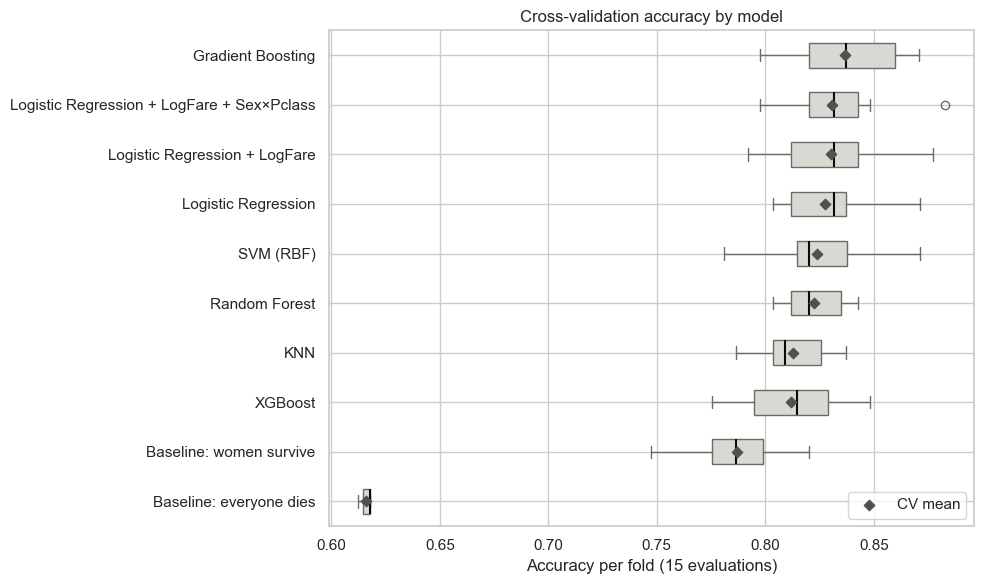

In [25]:
order = benchmark.index.tolist()
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([fold_scores[m] for m in order][::-1], vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#d9d8d3", color=NEUTRAL), medianprops=dict(color="#0b0b0b", linewidth=1.5),
           whiskerprops=dict(color=NEUTRAL), capprops=dict(color=NEUTRAL), flierprops=dict(markeredgecolor=NEUTRAL))
ax.scatter([fold_scores[m].mean() for m in order][::-1], range(1, len(order) + 1), color=INK, marker="D", zorder=3, s=28, label="CV mean")
ax.set_yticks(range(1, len(order) + 1), order[::-1])
ax.grid(axis="x", visible=True)
ax.set(xlabel="Accuracy per fold (15 evaluations)", title="Cross-validation accuracy by model")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
# Paired comparison: the best model vs every other model on the same 15 folds
best = benchmark.drop(index=[i for i in benchmark.index if i in ("Baseline: everyone dies", "Baseline: women survive")]).index[0]
paired = pd.DataFrame({
    "mean_diff_vs_best": {m: (fold_scores[best] - fold_scores[m]).mean() for m in MODELS if m != best},
    "std_of_diff": {m: (fold_scores[best] - fold_scores[m]).std() for m in MODELS if m != best},
    "best_wins_of_15": {m: int((fold_scores[best] > fold_scores[m]).sum()) for m in MODELS if m != best},
    "ties": {m: int((fold_scores[best] == fold_scores[m]).sum()) for m in MODELS if m != best},
}).sort_values("mean_diff_vs_best")
print("Best model:", best)
paired.round(4)

Best model: Gradient Boosting


,mean_diff_vs_best,std_of_diff,best_wins_of_15,ties
Logistic Regression + LogFare + Sex×Pclass,0.0060,0.0147,7,5
Logistic Regression + LogFare,0.0064,0.0143,9,2
Logistic Regression,0.0094,0.0171,11,0
SVM (RBF),0.0131,0.0179,12,1
Random Forest,0.0142,0.0216,9,2
KNN,0.0243,0.0193,13,1
XGBoost,0.0251,0.0117,14,0


> **📖 The race ends in a tie**
>
> - **Every model beats both baselines.** The best is about 5 points above the rule "women survive" (78.7%).
> - **The top four are practically tied:** Gradient Boosting **83.7%**, Logistic Regression **83.1%**. The gap is much smaller than the variation between splits (about ±2 points), and Gradient Boosting wins only 7 of the 15 splits.
> - **Some models memorize:** Random Forest and XGBoost reach 98% to 99% on the passengers they learned from but only 81% to 82% on new ones. Logistic Regression stays within 1 point.
> - The technical notes below check whether these differences are real.

### 🔧 Technical note A: are the differences real?

Every model is compared with **Logistic Regression + LogFare**.

| Test | Question | Assumes normality | Handles overlapping folds |
|---|---|---|---|
| Shapiro-Wilk | Are the fold differences normal? | not applicable | ❌ |
| Wilcoxon signed-rank | Is the median difference zero? | ❌ | ❌ |
| **Corrected resampled t-test** | Is the mean difference zero? | ✅ | ✅ |
| **Bayesian correlated t-test** | Is the difference *practically* relevant (ROPE ±1 point)? | ✅ | ✅ |
| **McNemar** | Do the models make different errors on the same passengers? | ❌ | ✅ (one partition at a time) |
| **Friedman + Nemenyi** | Do all models perform equally as a group? | ❌ | ❌ |

**Why a correction?** In 5-fold CV two training sets share 75% of their rows, so the 15 scores are **not independent** and standard tests find differences that are not there. The Nadeau and Bengio correction inflates the variance: $t = \bar d \,/\, \sqrt{(1/n + n_{test}/n_{train})\, \hat\sigma^2}$ with $n = 15$ and $n_{test}/n_{train} = 0.25$.

> **Reading p:** p is the chance of seeing a difference this large **if there were no real difference**. **Small p (below 0.05): surprising, the difference is significant.** Large p: not enough evidence, which is *not* proof of equality. Like a court: "not guilty" is not "innocent".

In [27]:
from scipy import stats

REFERENCE = "Logistic Regression + LogFare"
N_EVAL = len(FOLDS)
TEST_TRAIN_RATIO = 1 / (5 - 1)
ROPE = 0.01
challengers = [m for m in MODELS if m != REFERENCE]


def diffs(model):
    return fold_scores[model] - fold_scores[REFERENCE]


# 1. Assumption check
assumptions = pd.DataFrame({
    m: {
        "shapiro_W": stats.shapiro(diffs(m)).statistic,
        "shapiro_p": stats.shapiro(diffs(m)).pvalue,
        "skew": stats.skew(diffs(m)),
        "zero_diffs": int((np.abs(diffs(m)) < 1e-9).sum()),
        "wilcoxon_p": stats.wilcoxon(diffs(m), zero_method="zsplit").pvalue,
        "naive_t_p": stats.ttest_1samp(diffs(m), 0).pvalue,
    } for m in challengers
}).T
display(assumptions.round(3))

# How often does Shapiro detect clearly non-normal data with only 15 values? (2,000 simulations each)
rng = np.random.default_rng(SEED)
alternatives = {"chi2(3)": lambda: rng.chisquare(3, N_EVAL), "t(3)": lambda: rng.standard_t(3, N_EVAL),
                "uniform": lambda: rng.uniform(size=N_EVAL)}
print("Shapiro detection rate at n=15:", {name: round(np.mean([stats.shapiro(gen()).pvalue < 0.05 for _ in range(2000)]), 2)
                          for name, gen in alternatives.items()})

,shapiro_W,shapiro_p,skew,zero_diffs,wilcoxon_p,naive_t_p
Logistic Regression,0.914,0.159,0.347,5.0,0.130,0.150
Logistic Regression + LogFare + Sex×Pclass,0.949,0.511,-0.365,3.0,0.776,0.921
SVM (RBF),0.935,0.327,-0.406,3.0,0.172,0.108
KNN,0.971,0.868,0.138,2.0,0.006,0.003
Random Forest,0.974,0.917,0.171,1.0,0.181,0.203
Gradient Boosting,0.951,0.533,-0.120,2.0,0.111,0.118
XGBoost,0.956,0.623,-0.443,0.0,0.002,0.002


Shapiro detection rate at n=15: {'chi2(3)': np.float64(0.5), 't(3)': np.float64(0.26), 'uniform': np.float64(0.12)}


> - **Shapiro-Wilk rejects normality for no model** (p between 0.16 and 0.92) and skewness is small.
> - But "not rejected" is not "normal": with 15 values Shapiro catches clearly non-normal data only about 12% to 50% of the time.
> - Normality is still **theoretically reasonable**: each fold accuracy is a mean of about 178 right or wrong outcomes (central limit theorem).
> - **Choosing a test after a normality test is discouraged** (Rochon et al., 2012), so the tests were chosen by design.
> - ⚠️ **Independence is the bigger problem:** Wilcoxon gives p = 0.006 and 0.002 for KNN and XGBoost, almost the same as the *uncorrected* t-test. A non-parametric test does not fix overlapping folds.

In [28]:
# 2. Corrected resampled t-test and 3. Bayesian correlated t-test
rows = []
for m in challengers:
    d = diffs(m)
    se = np.sqrt((1 / N_EVAL + TEST_TRAIN_RATIO) * d.var(ddof=1))
    t_stat = d.mean() / se
    posterior = stats.t(df=N_EVAL - 1, loc=d.mean(), scale=se)
    rows.append({
        "model": m,
        "diff_points": d.mean() * 100,
        "ci95_low": posterior.ppf(0.025) * 100,
        "ci95_high": posterior.ppf(0.975) * 100,
        "p_corrected": 2 * stats.t.sf(abs(t_stat), N_EVAL - 1),
        "p_naive": stats.ttest_1samp(d, 0).pvalue,
        "P_worse": posterior.cdf(-ROPE),
        "P_equivalent": posterior.cdf(ROPE) - posterior.cdf(-ROPE),
        "P_better": posterior.sf(ROPE),
    })
significance = pd.DataFrame(rows).set_index("model").sort_values("diff_points", ascending=False)
print("Reference:", REFERENCE, "| ROPE = ±1 point")
significance.round(3)

Reference: Logistic Regression + LogFare | ROPE = ±1 point


,diff_points,ci95_low,ci95_high,p_corrected,p_naive,P_worse,P_equivalent,P_better
model,,,,,,,,
Gradient Boosting,0.638,-1.151,2.426,0.457,0.118,0.035,0.630,0.335
Logistic Regression + LogFare + Sex×Pclass,0.039,-1.777,1.855,0.964,0.921,0.120,0.742,0.138
Logistic Regression,-0.299,-1.217,0.619,0.496,0.150,0.062,0.934,0.004
SVM (RBF),-0.672,-2.502,1.158,0.444,0.108,0.353,0.612,0.035
Random Forest,-0.784,-3.525,1.958,0.550,0.203,0.434,0.474,0.092
KNN,-1.794,-4.082,0.495,0.115,0.003,0.765,0.225,0.010
XGBoost,-1.868,-4.145,0.410,0.100,0.002,0.786,0.205,0.009


> - **No difference is significant** after correction (all p above 0.05). Gradient Boosting's +0.64 points has a 95% interval of about [−1.2, +2.4], which contains zero.
> - The correction matters: the naive t-test calls KNN and XGBoost "significantly worse" (p = 0.003 and 0.002), the corrected test does not (p = 0.12 and 0.10).
> - **Bayesian view:** Gradient Boosting is **63% likely to be practically equivalent**, 34% better, 3% worse. `Sex × Pclass` (74%) and `LogFare` versus raw `Fare` (93%) are practically equivalent. KNN and XGBoost are about 78% likely to be worse.
> - With 891 passengers the intervals are about ±2 points wide: the data **cannot detect 1 point differences**.

In [29]:
# 4. McNemar: out-of-fold predictions, one 5-fold partition per repeat
from sklearn.model_selection import cross_val_predict


def oof_predictions(name, folds):
    prep, model, cols = MODELS[name]
    return cross_val_predict(make_pipeline(prep, model), train[cols], y, cv=folds)


mcnemar_rows = []
for rep in range(3):
    partition = FOLDS[rep * 5:(rep + 1) * 5]
    ref_correct = oof_predictions(REFERENCE, partition) == y
    for other in ["Gradient Boosting", "XGBoost"]:
        other_pred = oof_predictions(other, partition)
        other_correct = other_pred == y
        ref_only = int((ref_correct & ~other_correct).sum())
        other_only = int((~ref_correct & other_correct).sum())
        mcnemar_rows.append({
            "repeat": rep + 1, "model": other,
            "same_prediction_%": (ref_correct == other_correct).mean() * 100,
            "only_reference_right": ref_only, "only_other_right": other_only,
            "p_exact": stats.binomtest(min(ref_only, other_only), ref_only + other_only, 0.5).pvalue,
        })
display(pd.DataFrame(mcnemar_rows).set_index(["model", "repeat"]).round(3))

# 5. Friedman and Nemenyi over all models
score_matrix = pd.DataFrame({m: fold_scores[m] for m in MODELS})
chi2, p_friedman = stats.friedmanchisquare(*score_matrix.T.values)
avg_rank = score_matrix.rank(axis=1, ascending=False).mean().sort_values()
k = len(MODELS)
critical_difference = stats.studentized_range.ppf(0.95, k, np.inf) / np.sqrt(2) * np.sqrt(k * (k + 1) / (6 * N_EVAL))
print(f"Friedman chi2 = {chi2:.2f}, p = {p_friedman:.2g} | Nemenyi CD (alpha 0.05) = {critical_difference:.2f}")
pd.DataFrame({
    "avg_rank": avg_rank,
    "differs_from_best": avg_rank - avg_rank.iloc[0] > critical_difference,
    "differs_from_reference": (avg_rank - avg_rank[REFERENCE]).abs() > critical_difference,
}).round(2)

,,same_prediction_%,only_reference_right,only_other_right,p_exact
model,repeat,,,,
Gradient Boosting,1,91.919,32,40,0.410
XGBoost,1,88.215,60,45,0.172
Gradient Boosting,2,92.705,32,33,1.000
XGBoost,2,88.552,61,41,0.059
Gradient Boosting,3,92.368,30,38,0.396
XGBoost,3,89.113,56,41,0.155


Friedman chi2 = 38.48, p = 2.5e-06 | Nemenyi CD (alpha 0.05) = 2.71


,avg_rank,differs_from_best,differs_from_reference
Gradient Boosting,2.63,False,False
Logistic Regression + LogFare + Sex×Pclass,3.13,False,False
Logistic Regression + LogFare,3.60,False,False
Logistic Regression,4.37,False,False
Random Forest,4.40,False,False
SVM (RBF),4.77,False,False
KNN,6.50,True,True
XGBoost,6.60,True,True


> - **Logistic Regression and Gradient Boosting give the same answer for about 92% of passengers.** On the roughly 70 they disagree on, neither is significantly better (p between 0.40 and 1.00): they learned practically **the same rule**.
> - Against XGBoost, Logistic Regression is ahead in all 3 repeats, but not significantly (p between 0.06 and 0.17).
> - **Friedman:** not all models are equal (p < 0.001). **Nemenyi:** Gradient Boosting and both Logistic Regression + LogFare variants rank better than KNN and XGBoost; the top six cannot be separated. ⚠️ These tests assume independent blocks, so this is weaker evidence.
>
> **Conclusion of note A:** five tests with different assumptions agree: Gradient Boosting and Logistic Regression + LogFare are **statistically equivalent**. Under equivalence the simpler, interpretable model with fewer settings to tune is preferred (Cawley and Talbot, 2010); this is not a claim that simpler models always generalize better (Domingos, 1999).
>
> **References:** Dietterich (1998) *Neural Computation* 10(7) · Nadeau and Bengio (2003) *Machine Learning* 52(3) · Bouckaert and Frank (2004) *PAKDD* · Demšar (2006) *JMLR* 7 · Varma and Simon (2006) *BMC Bioinformatics* 7 · Cawley and Talbot (2010) *JMLR* 11 · Rochon, Gondan and Kieser (2012) *BMC Med. Res. Methodol.* 12 · Benavoli et al. (2017) *JMLR* 18 · Domingos (1999) *Data Min. Knowl. Discov.* 3(4)

### 🔧 Technical note B: more than accuracy

| Metric | Question | Remember it as |
|---|---|---|
| **Accuracy** | What share of predictions is correct? | overall grade |
| **Precision** | Of passengers predicted "survived", how many really survived? | how clean the survivor list is |
| **Recall** | Of the real survivors, how many were found? | how complete the survivor list is |
| **F1** | harmonic mean of precision and recall | finding survivors cleanly and completely |
| **ROC-AUC** | Does a random survivor get a higher probability than a random victim? | discrimination: 0.5 coin flip, 1.0 perfect |

In [30]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

METRICS = {"accuracy": accuracy_score, "f1": f1_score, "roc_auc": roc_auc_score,
           "precision": precision_score, "recall": recall_score}

metric_scores = {}
for name, (prep, model, cols) in MODELS.items():
    result = cross_validate(make_pipeline(prep, model), train[cols], y, cv=FOLDS, scoring=list(METRICS))
    metric_scores[name] = {m: result[f"test_{m}"] for m in METRICS}

# Baseline rule on the same folds (hard 0/1 predictions, so its ROC-AUC equals balanced accuracy)
gender_pred = (train["Sex"] == "female").astype(int)
metric_scores["Baseline: women survive"] = {
    m: np.array([fn(y.iloc[val], gender_pred.iloc[val]) for _, val in FOLDS]) for m, fn in METRICS.items()
}


def corrected_p(a, b):
    d = a - b
    se = np.sqrt((1 / N_EVAL + TEST_TRAIN_RATIO) * d.var(ddof=1))
    return 2 * stats.t.sf(abs(d.mean() / se), N_EVAL - 1)


multi = pd.DataFrame({
    name: {
        "accuracy": s["accuracy"].mean() * 100,
        "p_accuracy": np.nan if name == REFERENCE else corrected_p(s["accuracy"], metric_scores[REFERENCE]["accuracy"]),
        "f1": s["f1"].mean() * 100,
        "p_f1": np.nan if name == REFERENCE else corrected_p(s["f1"], metric_scores[REFERENCE]["f1"]),
        "roc_auc": s["roc_auc"].mean() * 100,
        "p_roc_auc": np.nan if name == REFERENCE else corrected_p(s["roc_auc"], metric_scores[REFERENCE]["roc_auc"]),
        "precision": s["precision"].mean() * 100,
        "recall": s["recall"].mean() * 100,
    } for name, s in metric_scores.items()
}).T.sort_values("accuracy", ascending=False)

n_tests = int(multi[["p_accuracy", "p_f1", "p_roc_auc"]].notna().sum().sum())
print(f"Reference: {REFERENCE} | tests {n_tests} → expected false positives at p < 0.05 ≈ {n_tests * 0.05:.1f}")
multi.round(3)

Reference: Logistic Regression + LogFare | tests 24 → expected false positives at p < 0.05 ≈ 1.2


,accuracy,p_accuracy,f1,p_f1,roc_auc,p_roc_auc,precision,recall
Gradient Boosting,83.688,0.457,77.626,0.767,87.884,0.261,81.827,74.085
Logistic Regression + LogFare + Sex×Pclass,83.089,0.964,76.535,0.604,87.242,0.460,81.806,72.039
Logistic Regression + LogFare,83.050,NaN,77.265,NaN,87.017,NaN,79.414,75.340
Logistic Regression,82.751,0.496,76.821,0.457,86.970,0.645,79.174,74.753
SVM (RBF),82.378,0.444,75.366,0.143,86.558,0.563,81.504,70.281
Random Forest,82.266,0.550,76.076,0.496,87.655,0.421,79.001,73.495
KNN,81.256,0.115,73.999,0.049,85.491,0.085,79.101,69.594
XGBoost,81.182,0.100,74.541,0.058,86.797,0.845,77.429,72.128
Baseline: women survive,78.675,0.001,70.970,0.001,76.687,0.000,74.257,68.126


> - **All three metrics agree:** Gradient Boosting is on top (accuracy 83.7, F1 77.6, ROC-AUC 87.9), but no difference from the reference is significant (p between 0.26 and 0.77).
> - **Every model clearly beats the rule "women survive"** (p ≤ 0.001). ROC-AUC jumps from about 77 to about 87: the clues add real discrimination beyond sex.
> - **KNN F1: p = 0.049**, formally significant. With 24 tests about 1 false positive is expected by chance, so it is treated as borderline.
> - **Random Forest** is 6th in accuracy but 2nd in ROC-AUC (87.7): it ranks passengers well but the 0.5 threshold cuts them poorly.
> - SVM and KNN are precise but miss more survivors (recall about 70%); Logistic Regression + LogFare is more balanced (79% precision, 75% recall).

### 🔧 Technical note C: a leak-free pipeline

In Chapter 3 some fill values were learned on the **whole train set before cross-validation**, so each validation fold helped compute its own fill values: a small **leak**. Every step that *learns from data* moves into the pipeline and is fitted on the training folds only.

| Step | Learns from data? | Leak risk | Where it lives now |
|---|---|---|---|
| Types, `Title`, `AgeMissing` | no, row by row | none | outside |
| `Age` from median by title | **yes** | ⚠️ | **pipeline** |
| `Embarked` from most frequent port | **yes** | ⚠️ | **pipeline** |
| `Fare` from median by class and port, then `LogFare` | **yes** | ⚠️ | **pipeline** |
| `GroupSize`, `CabinShare` | counts values, **no answers** | none | outside |
| Scaling and encoding | yes | already inside | pipeline |

In [31]:
from sklearn.base import BaseEstimator, TransformerMixin


class FoldImputer(BaseEstimator, TransformerMixin):
    """Learns fill values on the training folds only: Age by title, Embarked mode, Fare by class & port."""

    def fit(self, X, y=None):
        self.age_by_title_ = X.groupby("Title", observed=True)["Age"].median()
        self.age_overall_ = X["Age"].median()
        self.embarked_mode_ = X["Embarked"].mode()[0]
        self.fare_by_group_ = X.groupby(["Pclass", "Embarked"], observed=True)["Fare"].median()
        self.fare_overall_ = X["Fare"].median()
        return self

    def transform(self, X):
        X = X.copy()
        X["Age"] = X["Age"].fillna(X["Title"].map(self.age_by_title_).astype(float)).fillna(self.age_overall_)
        X["Embarked"] = X["Embarked"].fillna(self.embarked_mode_)
        group_fare = self.fare_by_group_.reindex(pd.MultiIndex.from_arrays([X["Pclass"], X["Embarked"]]))
        X["Fare"] = X["Fare"].fillna(pd.Series(group_fare.values, index=X.index)).fillna(self.fare_overall_)
        X["LogFare"] = np.log1p(X["Fare"])
        return X


# Model input with the ORIGINAL missing values restored; the pipeline fills them
IMPUTE_COLS = ["Title", "Pclass", "Embarked", "Age", "Fare", "LogFare"]
train_raw, test_raw = train.copy(), test.copy()
train_raw[["Age", "Embarked", "Fare"]] = train_before[["Age", "Embarked", "Fare"]]
test_raw[["Age", "Embarked", "Fare"]] = test_before[["Age", "Embarked", "Fare"]]
train_raw["LogFare"], test_raw["LogFare"] = np.nan, np.nan

# Sanity check: fitted on the full train, it must reproduce the section 9 values on test
check_imputer = FoldImputer().fit(train_raw)
filled_test = check_imputer.transform(test_raw)
print("Missing values left in test after filling:", filled_test[["Age", "Embarked", "Fare", "LogFare"]].isna().sum().sum())
print("Test ages identical to section 9:", bool((filled_test["Age"] == test["Age"]).all()))
print("Test Fare fill:", filled_test.loc[test_before["Fare"].isna(), "Fare"].tolist(), "| Embarked:", check_imputer.embarked_mode_)

Missing values left in test after filling: 0
Test ages identical to section 9: True
Test Fare fill: [8.05] | Embarked: S


In [32]:
clean_scores = {}
for name, (prep, model, cols) in MODELS.items():
    X = train_raw[list(dict.fromkeys(cols + IMPUTE_COLS))]
    result = cross_validate(make_pipeline(FoldImputer(), prep, model), X, y, cv=FOLDS, scoring=["accuracy", "f1", "roc_auc"])
    clean_scores[name] = {m: result[f"test_{m}"] for m in ["accuracy", "f1", "roc_auc"]}

leak_free = pd.DataFrame({
    name: {
        "accuracy_before": fold_scores[name].mean() * 100,
        "accuracy_leak_free": s["accuracy"].mean() * 100,
        "change_points": (s["accuracy"].mean() - fold_scores[name].mean()) * 100,
        "p_accuracy": np.nan if name == REFERENCE else corrected_p(s["accuracy"], clean_scores[REFERENCE]["accuracy"]),
        "f1": s["f1"].mean() * 100,
        "p_f1": np.nan if name == REFERENCE else corrected_p(s["f1"], clean_scores[REFERENCE]["f1"]),
        "roc_auc": s["roc_auc"].mean() * 100,
        "p_roc_auc": np.nan if name == REFERENCE else corrected_p(s["roc_auc"], clean_scores[REFERENCE]["roc_auc"]),
    } for name, s in clean_scores.items()
}).T.sort_values("accuracy_leak_free", ascending=False)
leak_free.round(3)

,accuracy_before,accuracy_leak_free,change_points,p_accuracy,f1,p_f1,roc_auc,p_roc_auc
Gradient Boosting,83.688,83.650,-0.037,0.514,77.569,0.810,87.694,0.410
Logistic Regression + LogFare,83.050,83.050,0.000,NaN,77.265,NaN,87.016,NaN
Logistic Regression + LogFare + Sex×Pclass,83.089,82.977,-0.112,0.928,76.388,0.519,87.229,0.481
Logistic Regression,82.751,82.751,0.000,0.496,76.821,0.457,86.972,0.663
SVM (RBF),82.378,82.378,0.000,0.444,75.366,0.143,86.505,0.532
Random Forest,82.266,82.229,-0.038,0.524,76.102,0.490,87.756,0.394
XGBoost,81.182,81.369,0.186,0.128,74.815,0.105,86.647,0.763
KNN,81.256,81.256,0.000,0.115,73.999,0.049,85.471,0.091


> - **The check passes:** fitted on the full train, `FoldImputer` reproduces Chapter 3 exactly on test (same ages, fare 8.05, port S).
> - **The leak was tiny:** accuracy changes by at most about 0.2 points, less than one passenger per fold.
> - **Conclusions unchanged.** From here on all modelling, including the final submission, uses this pipeline.

### 🔧 Technical note D: tuning with nested CV

If we try many settings and report the best score *on the same splits*, the score is optimistic: some settings win by luck (Varma and Simon, 2006; Cawley and Talbot, 2010). **Nested CV** puts a second CV inside the first.

```
OUTER loop (the same 15 splits)
 ├─ training part (4/5) ──► INNER 5-fold CV: try settings, pick the best
 └─ validation part (1/5) ─► score it, never used for choosing settings
```

> **The inner loop chooses, the outer loop judges.**

| Model | Search | Settings per inner search |
|---|---|---|
| Logistic Regression + LogFare | grid over regularization `C` | 12 |
| Gradient Boosting | random search: trees, learning rate, depth, leaf size, subsample, features | 40 |
| XGBoost | random search: trees, learning rate, depth, child weight, subsample, column sample, L2, gamma | 40 |

**Decision rule, fixed in advance:** a tuned challenger replaces Logistic Regression only if Bayesian P(better by more than 1 point) > 0.90 **or** corrected p < 0.05.

In [33]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

INNER_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
N_ITER = 40
SEARCH_SPACES = {
    "Logistic Regression + LogFare": {"model__C": np.logspace(-3, 2, 12)},
    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_samples_leaf": [1, 3, 5, 10, 20],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__max_features": [None, "sqrt", 0.5],
    },
    "XGBoost": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__min_child_weight": [1, 3, 5, 10],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.5, 0.7, 1.0],
        "model__reg_lambda": [0.1, 1, 5, 10],
        "model__gamma": [0, 0.5, 1],
    },
}


def make_search(name):
    prep, model, _ = MODELS[name]
    pipe = Pipeline([("impute", FoldImputer()), ("prep", prep), ("model", model)])
    space = SEARCH_SPACES[name]
    if len(space) == 1:
        return GridSearchCV(pipe, space, cv=INNER_CV, scoring="accuracy", n_jobs=-1)
    return RandomizedSearchCV(pipe, space, n_iter=N_ITER, cv=INNER_CV, scoring="accuracy", n_jobs=-1, random_state=SEED)


def model_input(name, df):
    return df[list(dict.fromkeys(MODELS[name][2] + IMPUTE_COLS))]


tuned = {}
for name in SEARCH_SPACES:
    X = model_input(name, train_raw)
    record = {"accuracy": [], "f1": [], "roc_auc": [], "inner_best": [], "params": []}
    start = time.time()
    for train_idx, val_idx in FOLDS:
        search = make_search(name).fit(X.iloc[train_idx], y.iloc[train_idx])
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        pred = search.predict(X_val)
        record["accuracy"].append(accuracy_score(y_val, pred))
        record["f1"].append(f1_score(y_val, pred))
        record["roc_auc"].append(roc_auc_score(y_val, search.predict_proba(X_val)[:, 1]))
        record["inner_best"].append(search.best_score_)
        record["params"].append(search.best_params_)
    tuned[name] = {k: (np.array(v) if k != "params" else v) for k, v in record.items()}
    print(f"{name}: {time.time() - start:.0f}s")

Logistic Regression + LogFare: 15s


Gradient Boosting: 219s


XGBoost: 59s


In [34]:
tuning_summary = pd.DataFrame({
    name: {
        "accuracy_default": clean_scores[name]["accuracy"].mean() * 100,
        "accuracy_tuned": r["accuracy"].mean() * 100,
        "change_points": (r["accuracy"].mean() - clean_scores[name]["accuracy"].mean()) * 100,
        "acc_std": r["accuracy"].std() * 100,
        "inner_best_score": r["inner_best"].mean() * 100,
        "optimism_points": (r["inner_best"].mean() - r["accuracy"].mean()) * 100,
        "f1": r["f1"].mean() * 100,
        "roc_auc": r["roc_auc"].mean() * 100,
    } for name, r in tuned.items()
}).T
display(tuning_summary.round(2))

# Stability: which setting did the inner search pick most often across the 15 outer folds?
for name, r in tuned.items():
    params = pd.DataFrame(r["params"]).astype(str)
    stability = pd.DataFrame({
        "most_common": params.apply(lambda s: s.value_counts().index[0]),
        "chosen_in": params.apply(lambda s: f"{s.value_counts().iloc[0]}/15"),
    })
    stability.index = stability.index.str.replace("model__", "")
    print(name)
    display(stability)

,accuracy_default,accuracy_tuned,change_points,acc_std,inner_best_score,optimism_points,f1,roc_auc
Logistic Regression + LogFare,83.05,83.09,0.04,2.08,83.37,0.28,77.38,87.02
Gradient Boosting,83.65,83.65,0.00,2.11,83.98,0.33,77.59,87.58
XGBoost,81.37,82.79,1.42,2.12,83.88,1.09,76.52,87.98


Logistic Regression + LogFare


,most_common,chosen_in
C,1.5199110829529332,4/15


Gradient Boosting


,most_common,chosen_in
subsample,1.0,7/15
n_estimators,200,8/15
min_samples_leaf,5,7/15
max_features,0.5,6/15
max_depth,3,6/15
learning_rate,0.05,6/15


XGBoost


,most_common,chosen_in
subsample,0.6,8/15
reg_lambda,0.1,9/15
n_estimators,200,8/15
min_child_weight,3,7/15
max_depth,4,7/15
learning_rate,0.1,8/15
gamma,0.0,7/15
colsample_bytree,0.7,10/15


In [35]:
# Decision rule: tuned challengers vs tuned Logistic Regression + LogFare on the same 15 outer folds
TUNED_REFERENCE = "Logistic Regression + LogFare"
decision_rows = []
for name in ["Gradient Boosting", "XGBoost"]:
    d = tuned[name]["accuracy"] - tuned[TUNED_REFERENCE]["accuracy"]
    se = np.sqrt((1 / N_EVAL + TEST_TRAIN_RATIO) * d.var(ddof=1))
    posterior = stats.t(df=N_EVAL - 1, loc=d.mean(), scale=se)
    p_value = 2 * stats.t.sf(abs(d.mean() / se), N_EVAL - 1)
    p_better = posterior.sf(ROPE)
    decision_rows.append({
        "model": name,
        "diff_points": d.mean() * 100,
        "p_corrected": p_value,
        "P_worse": posterior.cdf(-ROPE),
        "P_equivalent": posterior.cdf(ROPE) - posterior.cdf(-ROPE),
        "P_better": p_better,
        "replaces_reference": "YES" if (p_better > 0.90 or (p_value < 0.05 and d.mean() > 0)) else "no",
    })
pd.DataFrame(decision_rows).set_index("model").round(3)

,diff_points,p_corrected,P_worse,P_equivalent,P_better,replaces_reference
model,,,,,,
Gradient Boosting,0.563,0.584,0.071,0.593,0.335,no
XGBoost,-0.298,0.792,0.268,0.602,0.130,no


> - **Tuning barely helped the strong models:** Logistic Regression +0.04 points, Gradient Boosting ±0.00.
> - **XGBoost gained the most** (81.4% → 82.8%) by choosing milder settings.
> - **Nested CV caught an illusion:** XGBoost's inner score was 83.9%, its honest outer score 82.8%. The model with the largest search fooled itself the most.
> - **No sharp best setting:** the chosen values change from split to split, many settings score almost the same.
> - **Decision rule: no replacement.** Gradient Boosting: +0.56 points, p = 0.58, P(better by more than 1 point) = 0.34. XGBoost: −0.30 points, p = 0.79.
> - **All three models land at about 83%.** With these clues the ceiling is reached. **Final model: Logistic Regression + LogFare.**

## Chapter 5: What the Model Learned, and Where It Fails

The final model is fitted on all 891 passengers (with `C` chosen by cross-validation on the full train). To see its mistakes honestly, every passenger is predicted by a model that **did not learn from that passenger** (5 fold out-of-fold predictions).

*Note:* `C` is chosen on the full train here, so the accuracy below is slightly optimistic. The honest estimate is the nested CV score of 83.1%.

In [36]:
from sklearn.metrics import confusion_matrix

FINAL_MODEL_NAME = "Logistic Regression + LogFare"
X_final = model_input(FINAL_MODEL_NAME, train_raw)
final_search = make_search(FINAL_MODEL_NAME).fit(X_final, y)
final_model = final_search.best_estimator_
print("Chosen C:", round(final_search.best_params_["model__C"], 3))

# Odds multipliers: above 1 raises the odds of survival, below 1 lowers them
weights = pd.Series(np.exp(final_model.named_steps["model"].coef_[0]),
                    index=final_model.named_steps["prep"].get_feature_names_out())
weights.index = weights.index.str.replace("cat__", "").str.replace("num__", "")
pd.DataFrame({
    "raises_survival": weights.sort_values(ascending=False).head(6).index,
    "odds_x": weights.sort_values(ascending=False).head(6).round(2).values,
    "lowers_survival": weights.sort_values().head(6).index,
    "odds_x ": weights.sort_values().head(6).round(2).values,
})

Chosen C: 1.52


,raises_survival,odds_x,lowers_survival,odds_x
0,Title_Master,4.71,GroupSize_Large,0.26
1,GroupSize_Alone,2.72,Title_Mr,0.36
2,Sex_female,2.67,Sex_male,0.40
3,Pclass_1,1.84,Title_Rare,0.46
4,Title_Mrs,1.64,Pclass_3,0.47
5,CabinShare_Shared,1.62,CabinShare_NoCabin,0.68


In [37]:
oof_pred = cross_val_predict(final_model, X_final, y, cv=FOLDS[:5])
oof_proba = cross_val_predict(final_model, X_final, y, cv=FOLDS[:5], method="predict_proba")[:, 1]

cm = pd.DataFrame(confusion_matrix(y, oof_pred),
                  index=["actually died", "actually survived"],
                  columns=["predicted died", "predicted survived"])
display(cm)
print(f"Correct: {(oof_pred == y).mean():.1%} | victims recognized: {cm.iloc[0, 0] / cm.iloc[0].sum():.1%} | survivors found: {cm.iloc[1, 1] / cm.iloc[1].sum():.1%}")

story = train.assign(predicted=oof_pred, wrong=(oof_pred != y).astype(int))
story.groupby(["Sex", "Pclass"], observed=True).agg(
    passengers=("Survived", "size"),
    actual_survival=("Survived", "mean"),
    predicted_survival=("predicted", "mean"),
    wrong_predictions=("wrong", "sum"),
).round(2)

,predicted died,predicted survived
actually died,484,65
actually survived,82,260


Correct: 83.5% | victims recognized: 88.2% | survivors found: 76.0%


passengers  actual_survival  predicted_survival  \
Sex    Pclass                                                    
male   1              122             0.37                0.23   
       2              108             0.16                0.08   
       3              347             0.14                0.03   
female 1               94             0.97                1.00   
       2               76             0.92                0.95   
       3              144             0.50                0.78   

               wrong_predictions  
Sex    Pclass                     
male   1                      39  
       2                       8  
       3                      37  
female 1                       3  
       2                      10  
       3                      50

In [38]:
# The model's biggest surprises: survivors it was most sure had died, and victims it was most sure had survived
cols = ["Name", "Age", "Pclass", "Title", "GroupSize", "Fare"]
surprise_survivors = story.assign(p=oof_proba).query("Survived == 1 and predicted == 0").nsmallest(5, "p")
surprise_victims = story.assign(p=oof_proba).query("Survived == 0 and predicted == 1").nlargest(5, "p")
display(surprise_survivors[cols + ["p"]].rename(columns={"p": "predicted_survival_probability"}).round(2))
surprise_victims[cols + ["p"]].rename(columns={"p": "predicted_survival_probability"}).round(2)

,Name,Age,Pclass,Title,GroupSize,Fare,predicted_survival_probability
643,"Foo, Mr. Choong",30.0,3,Mr,Large,56.5,0.01
74,"Bing, Mr. Lee",32.0,3,Mr,Large,56.5,0.01
838,"Chip, Mr. Chang",32.0,3,Mr,Large,56.5,0.01
692,"Lam, Mr. Ali",30.0,3,Mr,Large,56.5,0.01
271,"Tornquist, Mr. William Henry",25.0,3,Mr,Small,0.0,0.02


,Name,Age,Pclass,Title,GroupSize,Fare,predicted_survival_probability
177,"Isham, Miss. Ann Elizabeth",50.0,1,Miss,Alone,28.71,0.91
498,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.0,1,Mrs,Large,151.55,0.90
297,"Allison, Miss. Helen Loraine",2.0,1,Miss,Large,151.55,0.88
312,"Lahtinen, Mrs. William (Anna Sylfven)",26.0,2,Mrs,Small,26.00,0.88
205,"Strom, Miss. Telma Matilda",2.0,3,Miss,Small,10.46,0.85


> **📖 The rule the model learned**
>
> - **What raises the odds:** being a boy (**Master**, the strongest clue), being a woman, travelling in **1st class**, sharing a cabin. **What lowers them:** travelling in a **large group** (the strongest negative clue), being an adult man (**Mr**), **3rd class**, no known cabin. The multipliers are relative to the other values of the same clue.
> - ⚠️ `GroupSize_Alone` looks positive (2.72) although alone passengers survived only 27%. This is not a contradiction: most lone travellers were adult men, and the model already counts that through **Mr**. *Among passengers with the same title and class*, being alone was better than being in a large group.
> - In one sentence: **women and children, especially from the upper classes, survived most often; adult men, 3rd class passengers and large families least often.** This is the pattern from Chapter 2, learned from the records alone.
>
> **📖 How well it separates survivors from victims**
>
> - About **5 out of 6 passengers** are predicted correctly. It recognizes victims better (about 88%) than it finds survivors (about 76%).
>
> **📖 Where it fails**
>
> - **3rd class women:** in reality only half survived, but the model expects most of them to survive. Being a woman is a strong clue, and in 3rd class it was not enough.
> - **Men who survived:** most men died, so the model rarely predicts survival for a man and misses most of the exceptions.
> - **The biggest surprises are real people:**
>   - Survivors the model gave almost no chance: **four men sharing ticket 1601** (Foo, Bing, Chip, Lam). Adult men, 3rd class, large group: every clue said "died", yet they survived.
>   - Victims the model was sure about: members of the **Allison family** from 1st class, including 2 year old **Helen Loraine Allison**.
> - Whatever decided their fate is **not recorded in the data**.

## Chapter 6: The 418 Hidden Passengers

The final pipeline (`FoldImputer` → encoding → Logistic Regression + LogFare, `C` chosen by cross-validation) was fitted on all 891 passengers in Chapter 5. It now predicts the passengers whose fate Kaggle keeps hidden and writes `submission.csv` in the format Kaggle expects: `PassengerId`, `Survived`.

These are **predictions, not facts**: the real answers stay with Kaggle.

In [39]:
X_test_final = model_input(FINAL_MODEL_NAME, test_raw)
test_pred = final_model.predict(X_test_final).astype(int)

submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": test_pred})
submission.to_csv("submission.csv", index=False)

sample = pd.read_csv(DATA_DIR / "gender_submission.csv")
saved = pd.read_csv("submission.csv")
pd.Series({
    "rows (expected 418)": len(saved),
    "columns match the sample file": list(saved.columns) == list(sample.columns),
    "PassengerId identical to the sample file": saved["PassengerId"].equals(sample["PassengerId"]),
    "PassengerId unique": saved["PassengerId"].is_unique,
    "only 0 and 1": set(saved["Survived"].unique()) <= {0, 1},
    "missing values": int(saved.isnull().sum().sum()),
    "% predicted survived": round(saved["Survived"].mean() * 100, 1),
    "% same as the 'women survive' sample": round((saved["Survived"] == sample["Survived"]).mean() * 100, 1),
}).to_frame("check")

,check
rows (expected 418),418
columns match the sample file,True
PassengerId identical to the sample file,True
PassengerId unique,True
only 0 and 1,True
missing values,0
% predicted survived,40.0
% same as the 'women survive' sample,91.6


In [40]:
# Predicted survival in test next to actual survival in train, by sex and class
pd.DataFrame({
    "train_passengers": train.groupby(["Sex", "Pclass"], observed=True)["Survived"].size(),
    "train_actual_survival": train.groupby(["Sex", "Pclass"], observed=True)["Survived"].mean(),
    "test_passengers": test.assign(pred=test_pred).groupby(["Sex", "Pclass"], observed=True)["pred"].size(),
    "test_predicted_survival": test.assign(pred=test_pred).groupby(["Sex", "Pclass"], observed=True)["pred"].mean(),
}).round(2)

train_passengers  train_actual_survival  test_passengers  \
Sex    Pclass                                                             
male   1                    122                   0.37               57   
       2                    108                   0.16               63   
       3                    347                   0.14              146   
female 1                     94                   0.97               50   
       2                     76                   0.92               30   
       3                    144                   0.50               72   

               test_predicted_survival  
Sex    Pclass                           
male   1                          0.21  
       2                          0.03  
       3                          0.08  
female 1                          1.00  
       2                          0.97  
       3                          0.88

> **📖 What the model predicts**
>
> - **The file is valid:** 418 rows, the same `PassengerId` order as Kaggle's sample file, only 0 and 1, no missing values.
> - The model predicts that **40%** of the hidden passengers survived, close to the 38% survival rate in train.
> - It agrees with the sample file "women survive" for **91.6%** of passengers; the model changes its answer for the rest, mainly using title, class and group size.
> - **The same weakness as in Chapter 5 is visible:** it predicts survival for 88% of 3rd class women in test, while in train only 50% of them survived. It predicts survival for very few men (3% to 21%), below the train rates (14% to 37%). Most errors on Kaggle's hidden answers are therefore expected in these two groups.
> - The Kaggle score will show how the model really does on these passengers. It may differ from the cross-validation estimate of about 83%.

## Epilogue: What the Data Told Us, and What It Could Not

| # | What we learned | Evidence |
|---|---|---|
| 1 | **Sex made the biggest difference** | women 74%, men 19% survived |
| 2 | **Class changed the pattern** | a 3rd class woman (50%) survived more often than a 1st class man (37%) |
| 3 | **Children survived more often, mainly boys** | age 0 to 5: 70%; boys (Master) 57% versus men (Mr) 16% |
| 4 | **Small groups survived more often than lone travellers and large groups** | alone 27%, small group 55%, large group 28% |
| 5 | **Missing records are not random** | no recorded age for 64% of Queenstown and 28% of 3rd class passengers |
| 6 | **A model can learn this story** | about 83% correct, versus 78.7% for "women survive" |
| 7 | **Simple was enough** | Logistic Regression and Gradient Boosting are statistically equivalent; tuning added nothing |

**What the data could not tell:** about one passenger in six does not fit the pattern, and the reasons behind their fate are not recorded in these columns.

**Submission:** `submission.csv` contains the predictions for the 418 hidden passengers. Kaggle's score will show how the model does on passengers it has never seen.